In [1]:
# Part A - Step 1: Load and inspect the dataset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# load dataset
df = pd.read_csv("./data/Absenteeism_at_work_CA_Q1.csv", header=None)

# basic inspection
print(df.head())
print(df.shape)
print(df.columns)
print(df.info())
print(df.describe())

# add header names
column_names = [
    "Individual identification (ID)",
    "Reason for absence (ICD)",
    "Month of absence",
    "Day of the week",
    "Seasons",
    "Transportation expense",
    "Distance from Residence to Work",
    "Service time",
    "Age",
    "Workload Average",
    "Hit target",
    "Disciplinary failure",
    "Education",
    "Son",
    "Social drinker",
    "Social smoker",
    "Pet",
    "Weight",
    "Height",
    "Body mass index",
    "Absenteeism"
]


df.columns = column_names

print(df.shape)
print(df.head())

#Part A - Step 2: Identify missing values

print("Missing values in each column:")
print(df.isnull().sum())

# show only columns with missing values
print("\nColumns with missing values only:")
print(df.isnull().sum()[df.isnull().sum() > 0])

# optional: view rows containing missing values
print("\nRows with missing values:")
print(df[df.isnull().any(axis=1)])

# Part A - Step 3: Handle missing data
print("HI")
print(df.columns.tolist())
# fill missing values
df['Reason for absence (ICD)'] = df['Reason for absence (ICD)'].fillna(df['Reason for absence (ICD)'].mode()[0])
df['Distance from Residence to Work'] = df['Distance from Residence to Work'].fillna(df['Distance from Residence to Work'].median())
df['Age'] = df['Age'].fillna(df['Age'].median())

# check that missing values are gone
print("Missing values after imputation:")
print(df.isnull().sum())


# Part A - Step 4: Check target and feature structure

# view column names
print("Columns in dataset:")
print(df.columns)

# drop ID column since it is only an identifier
df = df.drop("Individual identification (ID)", axis=1)

# define features and target
X = df.drop("Absenteeism", axis=1)
y = df["Absenteeism"]

# check results
print("\nFeature columns:")
print(X.columns)

print("\nTarget column:")
print(y.name)

print("\nX shape:", X.shape)
print("y shape:", y.shape)


# Part A - Step 5: Encode categorical variables where needed

# one-hot encode categorical columns
cat_cols = ['Reason for absence (ICD)', 'Month of absence', 'Day of the week', 'Seasons', 'Education']

df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# check the new dataframe
print(df_encoded.head())
print(df_encoded.info())

# Part A - Step 6: Select top attributes using correlation coefficients

# correlation matrix
corr_matrix = df_encoded.corr(numeric_only=True)

# correlation with target
target_corr = corr_matrix["Absenteeism"].abs().sort_values(ascending=False)

print("Correlation with Absenteeism:")
print(target_corr)

# remove the target itself and select top attributes
top_attributes = target_corr.drop("Absenteeism").head(10)

print("\nTop 10 attributes:")
print(top_attributes)

# store selected feature names
selected_features = top_attributes.index.tolist()

print("\nSelected features list:")
print(selected_features)

# Part A - Step 7: Create the final feature set

# create final dataset with selected features and target
X_selected = df_encoded[selected_features]
y = df_encoded["Absenteeism"]

print("Selected feature data:")
print(X_selected.head())

print("\nTarget data:")
print(y.head())

print("\nX_selected shape:", X_selected.shape)
print("y shape:", y.shape)

# Part A - Step 8: Apply standardisation where appropriate

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

print("Scaled feature data:")
print(X_scaled[:5])

# Part A - Step 9: Final preprocessed dataset ready for Part B

print("Preprocessing complete.")
print("Selected features:")
print(selected_features)

print("\nFinal feature set shape:", X_selected.shape)
print("Scaled feature set shape:", X_scaled.shape)
print("Target shape:", y.shape)

   0   1   2   3   4    5   6   7   8       9   ...  11  12  13  14  15  16  \
0  11  26   7   3   1  289  36  13  33  239554  ...   0   1   2   1   0   1   
1  36   0   7   3   1  118  13  18  50  239554  ...   1   1   1   1   0   0   
2   3  23   7   4   1  179  51  18  38  239554  ...   0   1   0   1   0   0   
3   7   7   7   5   1  279   5  14  39  239554  ...   0   1   2   1   1   0   
4  11  23   7   5   1  289  36  13  33  239554  ...   0   1   2   1   0   1   

   17   18  19  20  
0  90  172  30   0  
1  98  178  31   0  
2  89  170  31   0  
3  68  168  24   0  
4  90  172  30   0  

[5 rows x 21 columns]
(740, 21)
Index([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19,
       20],
      dtype='int64')
<class 'pandas.DataFrame'>
RangeIndex: 740 entries, 0 to 739
Data columns (total 21 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       740 non-null    int64
 1   1       740 non-null    int64
 2   2       740 non-n

SVM Accuracy: 0.8040540540540541
SVM Mean CV Accuracy: 0.8027027027027026
Best K: 5
KNN Accuracy: 0.8445945945945946
KNN Mean CV Accuracy: 0.8162162162162161
Decision Tree Accuracy: 0.8243243243243243
Decision Tree Mean CV Accuracy: 0.8108108108108109
|--- Reason for absence (ICD)_23 <= 0.50
|   |--- Reason for absence (ICD)_28 <= 0.50
|   |   |--- Reason for absence (ICD)_27 <= 0.50
|   |   |   |--- Disciplinary failure <= 0.50
|   |   |   |   |--- Transportation expense <= 240.50
|   |   |   |   |   |--- Reason for absence (ICD)_22 <= 0.50
|   |   |   |   |   |   |--- Reason for absence (ICD)_26 <= 0.50
|   |   |   |   |   |   |   |--- Transportation expense <= 156.00
|   |   |   |   |   |   |   |   |--- Transportation expense <= 136.50
|   |   |   |   |   |   |   |   |   |--- Reason for absence (ICD)_19 <= 0.50
|   |   |   |   |   |   |   |   |   |   |--- Reason for absence (ICD)_13 <= 0.50
|   |   |   |   |   |   |   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   

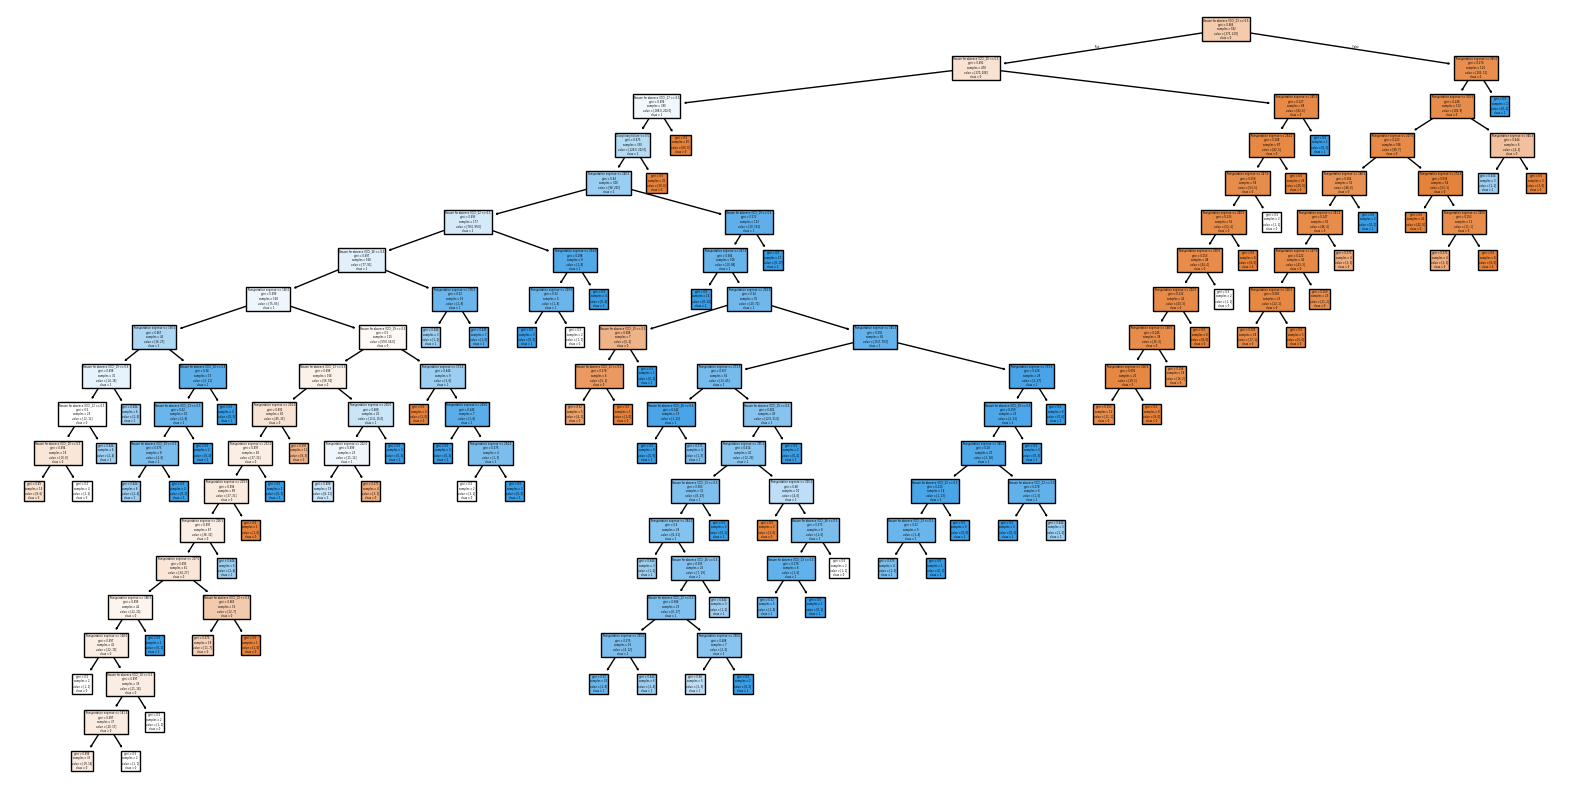

Naive Bayes Accuracy: 0.8175675675675675
Naive Bayes Mean CV Accuracy: 0.8054054054054054
Naive Bayes Prediction Probabilities:
[[1.00000000e+00 0.00000000e+00]
 [3.43338709e-17 1.00000000e+00]
 [5.75475324e-21 1.00000000e+00]
 [1.45247217e-03 9.98547528e-01]
 [9.99952145e-01 4.78551735e-05]
 [9.99455651e-01 5.44348818e-04]
 [9.99936114e-01 6.38860170e-05]
 [2.12442302e-03 9.97875577e-01]
 [1.99791466e-17 1.00000000e+00]
 [8.96149581e-01 1.03850419e-01]]
Mean Cross-Validation Accuracies:
SVM: 0.8027
KNN: 0.8162
Decision Tree: 0.8108
Naive Bayes: 0.8054
Best Model: KNN
Model and scaler saved successfully.
Model loaded successfully.
['Reason for absence (ICD)_23', 'Reason for absence (ICD)_28', 'Reason for absence (ICD)_22', 'Reason for absence (ICD)_27', 'Transportation expense', 'Reason for absence (ICD)_19', 'Reason for absence (ICD)_13', 'Reason for absence (ICD)_10', 'Disciplinary failure', 'Reason for absence (ICD)_26']
   Reason for absence (ICD)_23  Reason for absence (ICD)_28  \

In [ ]:
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import joblib

# train-test split
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

X_train, X_test, y_train2, y_test2 = train_test_split(
    X_selected, y, test_size=0.2, random_state=42
)

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ---------------- SVM ----------------
svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_accuracy = accuracy_score(y_test, svm_pred)
svm_cv_scores = cross_val_score(svm_model, X_scaled, y, cv=kf, scoring='accuracy')

print("SVM Accuracy:", svm_accuracy)
print("SVM Mean CV Accuracy:", svm_cv_scores.mean())

# ---------------- KNN ----------------
k_values = range(1, 21)
k_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    pred_k = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, pred_k)
    k_accuracies.append(acc)

best_k = k_values[k_accuracies.index(max(k_accuracies))]
print("Best K:", best_k)

knn_model = KNeighborsClassifier(n_neighbors=best_k)
knn_model.fit(X_train_scaled, y_train)
knn_pred = knn_model.predict(X_test_scaled)
knn_accuracy = accuracy_score(y_test, knn_pred)
knn_cv_scores = cross_val_score(knn_model, X_scaled, y, cv=kf, scoring='accuracy')

print("KNN Accuracy:", knn_accuracy)
print("KNN Mean CV Accuracy:", knn_cv_scores.mean())

# ---------------- Decision Tree ----------------
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train2)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test2, dt_pred)
dt_cv_scores = cross_val_score(dt_model, X_selected, y, cv=kf, scoring='accuracy')

print("Decision Tree Accuracy:", dt_accuracy)
print("Decision Tree Mean CV Accuracy:", dt_cv_scores.mean())

tree_text = export_text(dt_model, feature_names=list(X_selected.columns))
print(tree_text)

plt.figure(figsize=(20, 10))
plot_tree(dt_model, feature_names=X_selected.columns, class_names=['0', '1'], filled=True)
plt.savefig("decision_tree.png")
plt.show()

# ---------------- Naive Bayes ----------------
nb_model = GaussianNB()
nb_model.fit(X_train, y_train2)
nb_pred = nb_model.predict(X_test)
nb_accuracy = accuracy_score(y_test2, nb_pred)
nb_cv_scores = cross_val_score(nb_model, X_selected, y, cv=kf, scoring='accuracy')

print("Naive Bayes Accuracy:", nb_accuracy)
print("Naive Bayes Mean CV Accuracy:", nb_cv_scores.mean())

nb_prob = nb_model.predict_proba(X_test)
print("Naive Bayes Prediction Probabilities:")
print(nb_prob[:10])

# ---------------- Compare models ----------------
results = {
    "SVM": svm_cv_scores.mean(),
    "KNN": knn_cv_scores.mean(),
    "Decision Tree": dt_cv_scores.mean(),
    "Naive Bayes": nb_cv_scores.mean()
}

print("Mean Cross-Validation Accuracies:")
for model_name, score in results.items():
    print(f"{model_name}: {score:.4f}")

best_model_name = max(results, key=results.get)
print("Best Model:", best_model_name)

# ---------------- Final model ----------------
if best_model_name == "SVM":
    final_model = SVC(probability=True, random_state=42)
    final_model.fit(X_scaled, y)
elif best_model_name == "KNN":
    final_model = KNeighborsClassifier(n_neighbors=best_k)
    final_model.fit(X_scaled, y)
elif best_model_name == "Decision Tree":
    final_model = DecisionTreeClassifier(random_state=42)
    final_model.fit(X_selected, y)
else:
    final_model = GaussianNB()
    final_model.fit(X_selected, y)

joblib.dump(final_model, "best_absenteeism_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully.")

# ---------------- Load model ----------------
loaded_model = joblib.load("best_absenteeism_model.pkl")
loaded_scaler = joblib.load("scaler.pkl")

print("Model loaded successfully.")

# ---------------- User input prediction ----------------
#new_data = []
#for feature in selected_features:
#    value = float(input(f"Enter value for {feature}: "))
#    new_data.append(value)

#new_data_df = pd.DataFrame([new_data], columns=selected_features)

print(selected_features)

new_data_dict = {
    selected_features[0]: 1,
    selected_features[1]: 30,
    selected_features[2]: 10,
    selected_features[3]: 250,
    selected_features[4]: 95,
    selected_features[5]: 0,
    selected_features[6]: 1,
    selected_features[7]: 2,
    selected_features[8]: 35,
    selected_features[9]: 24
}

new_data_df = pd.DataFrame([new_data_dict])
print(new_data_df)
print(selected_features)

if best_model_name in ["SVM", "KNN"]:
    new_data_scaled = loaded_scaler.transform(new_data_df)
    prediction = loaded_model.predict(new_data_scaled)
    probability = loaded_model.predict_proba(new_data_scaled)
else:
    prediction = loaded_model.predict(new_data_df)
    probability = loaded_model.predict_proba(new_data_df)

print("Prediction:", prediction[0])
print("Prediction Probability:", probability)